<a href="https://colab.research.google.com/github/Zinc-zn/PVCK_Ganjil_2026/blob/main/PraktikumModul2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving KTPDummy.jpg to KTPDummy.jpg


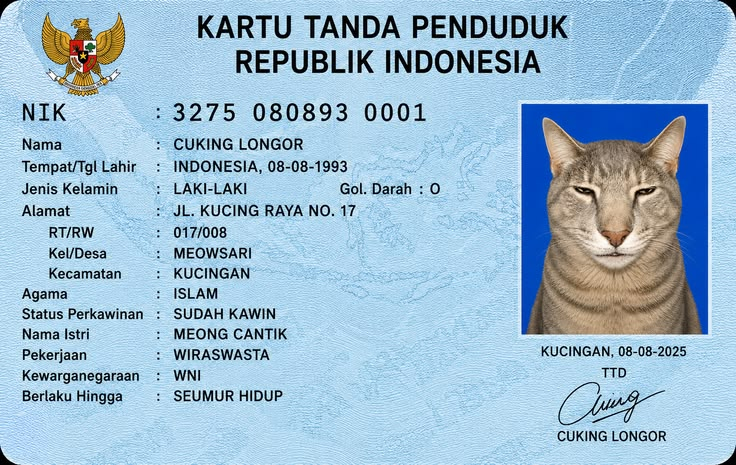

Resolusi gambar:  736  x  465


In [ ]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

img = cv.imread('KTPDummy.jpg')
cv2_imshow(img)

print("Resolusi gambar: ", img.shape[1], " x ", img.shape[0])

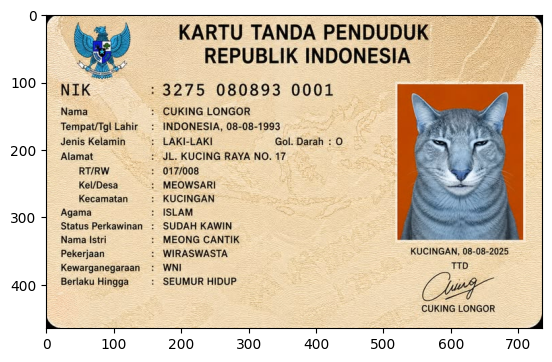

In [ ]:
img = cv.imread('KTPDummy.jpg')
plt.imshow(img)

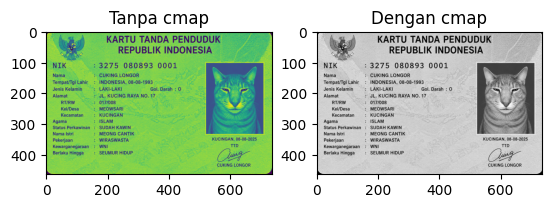

In [ ]:
img_gray = cv.imread('KTPDummy.jpg', cv.IMREAD_GRAYSCALE)

# Tanpa cmap
plt.subplot(1,2,1)
plt.imshow(img_gray)
plt.title('Tanpa cmap')

# Dengan cmap
plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='gray')
plt.title('Dengan cmap')

plt.show()

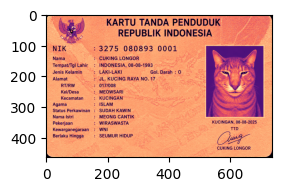

In [ ]:
img_gray = cv.imread('KTPDummy.jpg', cv.IMREAD_GRAYSCALE)

plt.subplot(1,2,2)
plt.imshow(img_gray, cmap='magma')

plt.show()

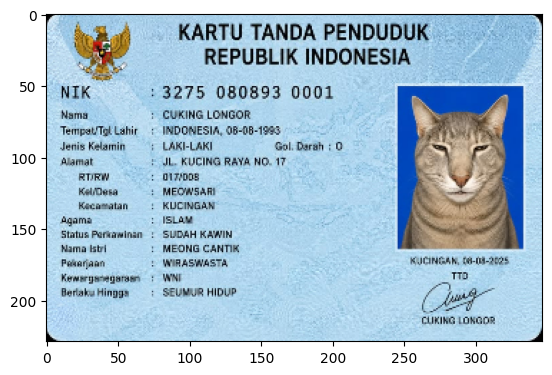

In [ ]:
imgRGB = cv.cvtColor(img,cv.COLOR_BGR2RGB) #konversi BGR ke RGB
img_output = cv.resize(imgRGB, (347,229))
plt.imshow(img_output)

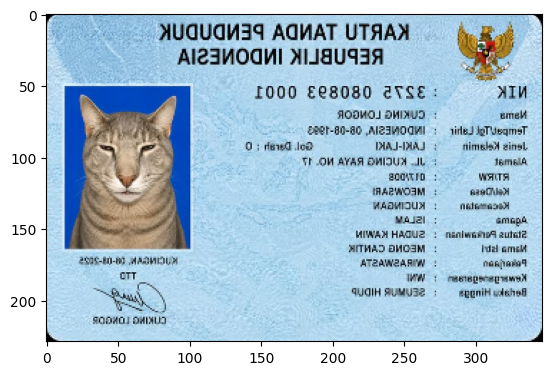

In [ ]:
imgFlip=cv.flip(img_output,1)
plt.imshow(imgFlip)

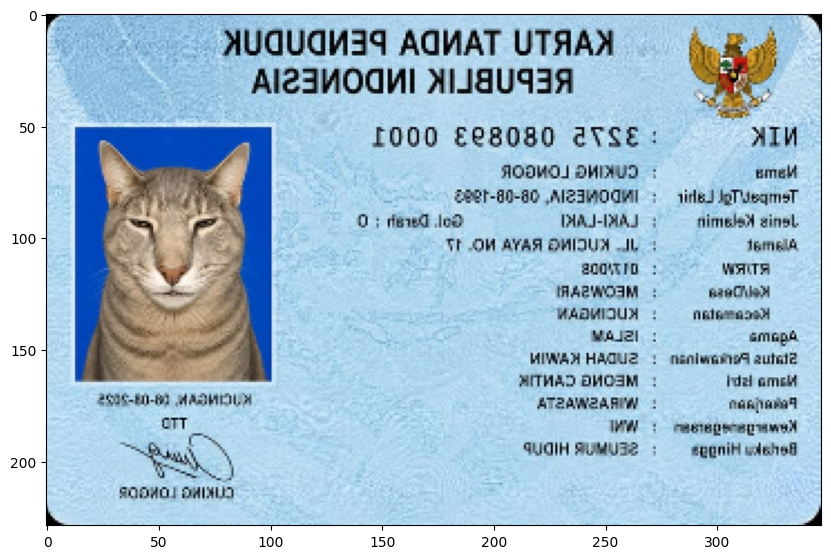

In [ ]:
imgFlip=cv.flip(img_output,1)

#tampilkan ukuran canvas yang lebih besar
fig = plt.figure(figsize=(10,10))
ax=fig.add_subplot(1,1,1)
ax.imshow(imgFlip)

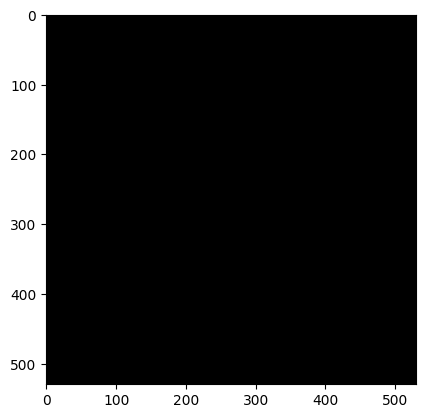

In [ ]:
black_img = np.zeros(shape=(530,530,3),dtype=np.int16)
plt.imshow(black_img)

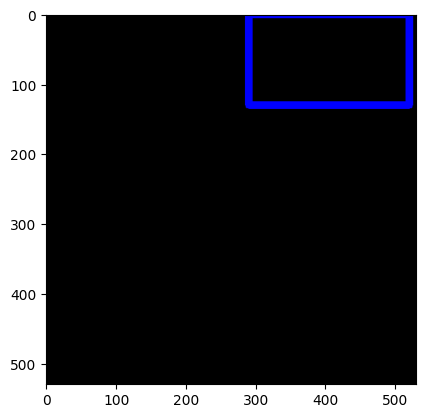

In [ ]:
#perhatikan koordinat titik2 pt1 dan pt2
cv.rectangle(black_img,pt1=(290,0),pt2=(520,130),color=(0,0,255),thickness=10)
plt.imshow(black_img)

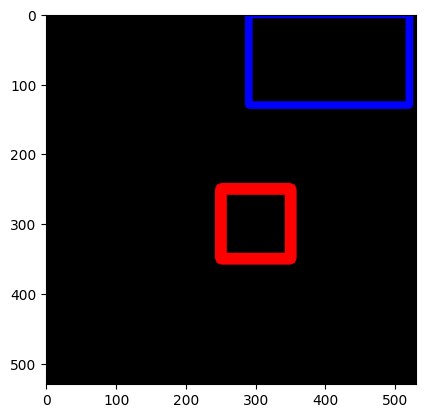

In [ ]:
cv.rectangle(black_img,pt1=(250,250),pt2=(350,350),color=(255,0,0),thickness=15)
plt.imshow(black_img)

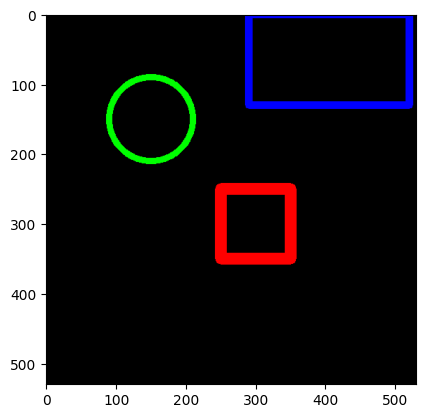

In [ ]:
cv.circle(black_img,center=(150,150),radius=60,color=(0,255,0),thickness=8)
plt.imshow(black_img)

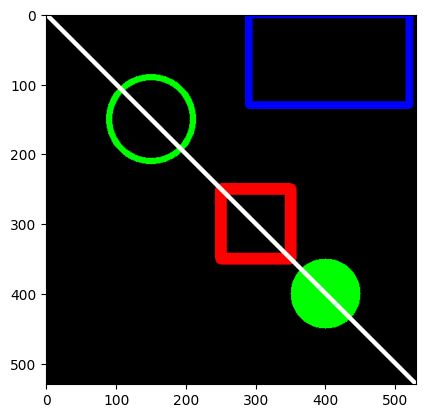

In [ ]:
cv.circle(black_img,center=(400,400),radius=50,color=(0,255,0),thickness=-1)
cv.line(black_img,pt1=(0,0),pt2=(530,530),color=(255,255,255),thickness=5)
plt.imshow(black_img)

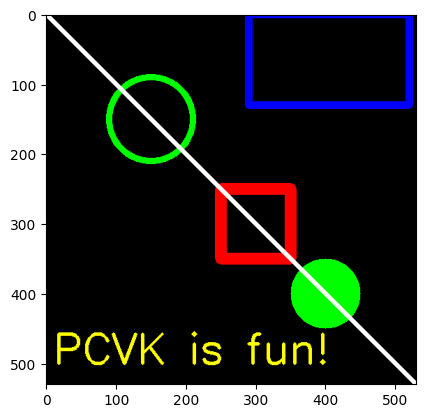

In [ ]:
font = cv.FONT_HERSHEY_SIMPLEX
cv.putText(black_img,text='PCVK is fun!',org=(10,500),fontFace=font,fontScale=2,
           color=(255,255,0),thickness=3,lineType=cv.LINE_AA)
plt.imshow(black_img)

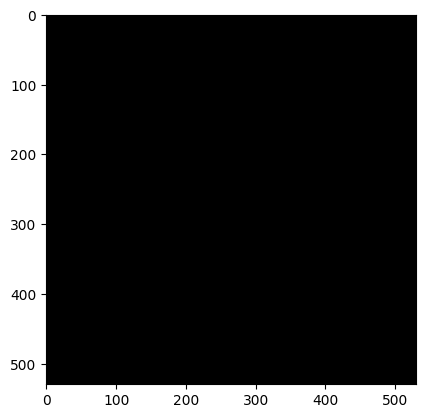

In [ ]:
black_img2=np.zeros(shape=(530,530,3),dtype=np.int32)
plt.imshow(black_img2)

In [ ]:
vertices = np.array([[150,350],[250,250],[450,350],[250,450]],dtype=np.int32)
vertices

array([[150, 350],
       [250, 250],
       [450, 350],
       [250, 450]], dtype=int32)

In [ ]:
pts = vertices.reshape((-1,1,2)) # nilai 2 untuk menunjukkan bahwa tiap titik dibuat 3 channel yg mewakili R, G, dan B
pts

array([[[150, 350]],

       [[250, 250]],

       [[450, 350]],

       [[250, 450]]], dtype=int32)

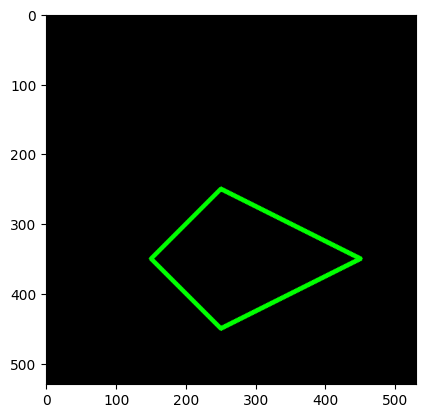

In [ ]:
cv.polylines(black_img2,[pts],isClosed=True,color=(0,255,0),thickness=5)
plt.imshow(black_img2)

## PERTANYAAN PRAKTIKUM

**1. Tampilkan satu citra bebas menggunakan cv2_imshow() dan plt.imshow() tanpa konversi warna apa pun. Mengapa hasilnya berbeda? Buktikan dengan mencetak nilai satu piksel yang sama dari kedua cara pembacaan tersebut.**

**Jawaban:** Hasilnya berbeda karena OpenCV (`cv.imread`) membaca citra dalam format BGR (Blue-Green-Red), sedangkan Matplotlib (`plt.imshow`) menampilkan citra dengan asumsi format RGB (Red-Green-Blue). Oleh karena itu, saluran warna biru dan merah saling tertukar jika citra ditampilkan menggunakan `plt.imshow` tanpa dikonversi terlebih dahulu.

In [ ]:
# Pembuktian Pertanyaan 1
import cv2 as cv
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import numpy as np

img_test = cv.imread('KTPDummy.jpg') # Pastikan gambar ini sudah ada di environment
if img_test is not None:
    print("Tampilan dengan cv2_imshow (BGR):")
    cv2_imshow(img_test)
    
    print("\nTampilan dengan plt.imshow (dianggap RGB padahal BGR):")
    plt.imshow(img_test)
    plt.show()
    
    # Ambil nilai satu piksel, misalnya pada koordinat (100, 100)
    pixel_bgr = img_test[100, 100]
    print(f"\nNilai piksel pada (100, 100) asli yang dibaca OpenCV (BGR): {pixel_bgr}")
    print("Terlihat bahwa warna Merah dan Biru tertukar ketika ditampilkan di plt.imshow")


**2. Buat kanvas hitam berukuran sama dengan tipe data int16 dan int32. Bandingkan dtype, min(), max(), dan nbytes keduanya. Apakah tampilannya berbeda? Apakah ukuran memorinya berbeda? Jelaskan alasannya.**

**Jawaban:** Tampilannya sama (keduanya berwarna hitam penuh karena nilainya 0), namun ukuran memorinya berbeda. Hal ini karena tipe data `int16` menggunakan 16 bit (2 byte) untuk menyimpan setiap angka, sedangkan `int32` menggunakan 32 bit (4 byte). Sehingga total `nbytes` kanvas `int32` akan dua kali lipat lebih besar dibandingkan `int16` meskipun secara visual pixel nya terlihat sama.

In [ ]:
# Pembuktian Pertanyaan 2
canvas_int16 = np.zeros((100, 100, 3), dtype=np.int16)
canvas_int32 = np.zeros((100, 100, 3), dtype=np.int32)

print("Kanvas int16:")
print("dtype:", canvas_int16.dtype)
print("min:", canvas_int16.min())
print("max:", canvas_int16.max())
print("nbytes:", canvas_int16.nbytes, "bytes")

print("\nKanvas int32:")
print("dtype:", canvas_int32.dtype)
print("min:", canvas_int32.min())
print("max:", canvas_int32.max())
print("nbytes:", canvas_int32.nbytes, "bytes")


**3. Apa kegunaan baris `from google.colab.patches import cv2_imshow`, dan mengapa `cv2.imshow()` bawaan OpenCV tidak dapat dipakai di Google Colab?**

**Jawaban:** Baris tersebut berguna untuk mengimpor fungsi penampil gambar dari antarmuka Colab (`cv2_imshow`) agar dapat merender gambar (numpy array) di sel keluaran notebook. `cv2.imshow()` bawaan dari OpenCV tidak bisa dipakai di Google Colab karena membutuhkan akses ke GUI host lokal untuk membuat layar *window* interaktif, sementara Colab berjalan di environment web/browser yang berada di server cloud sehingga memblokir panggilan window OS lokal.

**4. Citra yang dibaca dengan skimage.io.imread() ditampilkan berdampingan dengan hasil cv2.cvtColor(img, cv2.COLOR_BGR2RGB) atas citra yang sama. Manakah yang menampilkan warna sebenarnya, dan manakah yang kanalnya tertukar? Buktikan dengan nilai piksel, bukan dengan pengamatan visual saja.**

**Jawaban:** Keduanya akan menampilkan warna yang sebenarnya saat dirender melalui `plt.imshow` karena `skimage.io.imread()` membaca citra secara langsung dalam format **RGB**. Keduanya tidak ada yang kanalnya tertukar apabila dicetak nilainya ke array. Namun jika `cv2.imread()` langsung disajikan di layar via matplotlib tanpa `cvtColor`, salurannya menjadi tertukar.

In [ ]:
# Pembuktian Pertanyaan 4
from skimage import io

if img_test is not None:
    img_skimage = io.imread('KTPDummy.jpg')
    img_cv2_rgb = cv.cvtColor(img_test, cv.COLOR_BGR2RGB)
    
    print("Nilai 1 piksel (100, 100) skimage (RGB) :", img_skimage[100, 100])
    print("Nilai 1 piksel (100, 100) cv2_rgb (RGB) :", img_cv2_rgb[100, 100])
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_skimage)
    axes[0].set_title('skimage (RGB)')
    axes[0].axis('off')
    
    axes[1].imshow(img_cv2_rgb)
    axes[1].set_title('cv2 cvtColor BGR2RGB (RGB)')
    axes[1].axis('off')
    plt.show()


**5. Setelah citra ditampilkan dengan figsize yang jauh lebih besar, apakah nilai img.shape ikut berubah? Jelaskan perbedaan antara mengubah ukuran citra dan mengubah ukuran tampilan.**

**Jawaban:** Nilai `img.shape` **tidak ikut berubah**. Mengubah ukuran citra (seperti menggunakan `cv2.resize()`) akan mengubah besaran baris/kolom array piksel pada matriks internal sehingga `img.shape` dan ukuran memorinya berubah secara harfiah. Sementara mengubah ukuran tampilan (seperti `figsize` pada matplotlib) hanyalah mengatur *zoom* pada tingkat *render canvas* visual di layar saat output tanpa merubah nilai atau dimensi array gambarnya sedikitpun.

In [ ]:
# Pembuktian Pertanyaan 5
if img_test is not None:
    shape_awal = img_test.shape
    print("Shape citra sebelum ditampilkan dengan figsize besar:", shape_awal)
    
    plt.figure(figsize=(15, 10))
    plt.imshow(cv.cvtColor(img_test, cv.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    
    print("Shape citra sesudah ditampilkan dengan figsize besar:", img_test.shape)


## TUGAS PRAKTIKUM - Penerapan

**1. Tampilkan citra hanya pada kombinasi kanal Merah-Biru dan kanal Hijau-Biru saja, dengan kanal yang tidak dipakai dinolkan. Susun keduanya berdampingan dalam satu figure yang diberi judul.**

In [ ]:
# Penerapan 1
if img_test is not None:
    # Konversi ke RGB untuk proses manipulasi (R, G, B)
    img_rgb = cv.cvtColor(img_test, cv.COLOR_BGR2RGB)
    
    # Kombinasi Merah-Biru (Hijau dinolkan)
    # Indeks RGB: R=0, G=1, B=2
    img_rb = img_rgb.copy()
    img_rb[:, :, 1] = 0 # Kanal hijau (G) menjadi 0
    
    # Kombinasi Hijau-Biru (Merah dinolkan)
    img_gb = img_rgb.copy()
    img_gb[:, :, 0] = 0 # Kanal merah (R) menjadi 0
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle('Kombinasi Kanal Warna')
    
    axes[0].imshow(img_rb)
    axes[0].set_title('Merah - Biru (G dinolkan)')
    axes[0].axis('off')
    
    axes[1].imshow(img_gb)
    axes[1].set_title('Hijau - Biru (R dinolkan)')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

**2. Tampilkan citra dalam tiga bentuk pencerminan: vertikal, horizontal, dan keduanya, dalam satu figure berisi tiga subplot yang masing-masing diberi label.**

In [ ]:
# Penerapan 2
if img_test is not None:
    img_rgb = cv.cvtColor(img_test, cv.COLOR_BGR2RGB)
    
    # Pencerminan: 0 untuk Vertikal, 1 untuk Horizontal, -1 untuk Keduanya
    img_vertikal = cv.flip(img_rgb, 0)
    img_horizontal = cv.flip(img_rgb, 1)
    img_keduanya = cv.flip(img_rgb, -1)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(img_vertikal)
    axes[0].set_title('Pencerminan Vertikal')
    axes[0].axis('off')
    
    axes[1].imshow(img_horizontal)
    axes[1].set_title('Pencerminan Horizontal')
    axes[1].axis('off')
    
    axes[2].imshow(img_keduanya)
    axes[2].set_title('Pencerminan Keduanya')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

**3. Gambarkan sebuah rectangle dan sebuah circle pada bagian wajah / badan dari foto aktivitas Anda sendiri (bukan pasfoto), lalu tambahkan teks berisi nama Anda dengan pilihan font, ukuran, dan warna yang Anda tentukan sendiri.**

In [ ]:
# Penerapan 3
if img_test is not None:
    # Untuk simulasi, kita menggunakan img_test sebagai dummy
    # Anda disarankan mengganti image path dengan foto aktivitas pribadi Anda
    img_draw = img_test.copy()
    
    H, W, C = img_draw.shape
    
    # Menggambar Rectangle (misal seolah membingkai badan)
    start_point = (int(W*0.3), int(H*0.2))
    end_point = (int(W*0.7), int(H*0.8))
    color_rect = (0, 255, 0) # Hijau di BGR
    cv.rectangle(img_draw, start_point, end_point, color_rect, 5)
    
    # Menggambar Circle (di area kepala misal)
    center_coordinates = (int(W*0.5), int(H*0.4))
    radius = int(min(H, W) * 0.15)
    color_circ = (0, 0, 255) # Merah di BGR
    cv.circle(img_draw, center_coordinates, radius, color_circ, 5)
    
    # Tambahkan Teks
    font = cv.FONT_HERSHEY_TRIPLEX
    text = "Nama Anda (NIM)"
    cv.putText(img_draw, text, (int(W*0.1), int(H*0.1)), font, fontScale=H/600.0, color=(255, 0, 0), thickness=2, lineType=cv.LINE_AA)
    
    # Konversi untuk ditampilkan di Matplotlib
    img_draw_rgb = cv.cvtColor(img_draw, cv.COLOR_BGR2RGB)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(img_draw_rgb)
    plt.title('Gambar dengan Rectangle, Circle, dan Teks')
    plt.axis('off')
    plt.show()

## TUGAS PRAKTIKUM - Analisa

**1. Rumuskan satu pertanyaan tentang citra digital yang dapat Anda jawab menggunakan kode dari modul ini. Contoh pertanyaan: berapa persen piksel pada foto KTM Anda yang lebih gelap dari nilai 100? apakah mengecilkan lalu membesarkan citra mengubah rata-rata intensitasnya? Tuliskan pertanyaan Anda, rancangan program, data hasilnya, dan kesimpulan Anda.**

**Pertanyaan:** 
Berapa persentase piksel pada saluran merah (Red) yang memiliki nilai intensitas sangat terang (di atas 200) pada citra? Apakah hal tersebut merepresentasikan pencahayaan gambar secara signifikan?

**Rancangan Program:**
1. Membaca citra yang akan diuji dan diubah formatnya ke RGB.
2. Memisahkan array matriks untuk mengekstrak hanya saluran merah (indeks ke-0).
3. Menghitung akumulasi total seluruh piksel pada citra tersebut.
4. Melakukan kondisi pengecekan nilai array piksel `> 200` pada numpy dan menghitung total kemunculannya.
5. Mendapatkan rasio persentase dan mencetaknya.

**Kesimpulan:**
Dengan melihat persentase yang dihasilkan, kita bisa mendapatkan insight seberapa mendominasinya pencahayaan warna kemerahan (warm/bright tone) yang berlebihan atau sangat cerah pada foto tersebut.

In [ ]:
# Analisa
if img_test is not None:
    img_rgb = cv.cvtColor(img_test, cv.COLOR_BGR2RGB)
    
    # Ekstrak saluran merah (R berada di index 0 setelah RGB)
    channel_red = img_rgb[:, :, 0]
    
    # Total piksel
    total_pixels = channel_red.size
    
    # Menghitung piksel merah bernilai di atas 200
    pixels_red_bright = np.sum(channel_red > 200)
    
    # Persentase
    percentage = (pixels_red_bright / total_pixels) * 100
    
    print(f"Total piksel dalam gambar: {total_pixels}")
    print(f"Jumlah piksel merah dengan intensitas > 200: {pixels_red_bright}")
    print(f"Persentase piksel super cerah merah: {percentage:.2f}%")


## TUGAS PRAKTIKUM - Aplikasi

### Studi Kasus 1

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def add_label(img):
    img_out = img.copy()
    H, W, C = img_out.shape
    
    bar_height = H // 12
    
    # Draw black bar at the bottom
    cv.rectangle(img_out, (0, H - bar_height), (W, H), (0, 0, 0), -1)
    
    text = "Dokumentasi PCVK - 2026"
    font = cv.FONT_HERSHEY_SIMPLEX
    
    # Adaptive font scale and thickness based on height
    font_scale = H / 1000.0
    thickness = max(1, H // 400)
    
    # Calculate text size to vertically center it in the bar
    (text_w, text_h), baseline = cv.getTextSize(text, font, font_scale, thickness)
    padding_x = int(W * 0.02)
    padding_y = H - (bar_height - text_h) // 2
    
    cv.putText(img_out, text, (padding_x, padding_y), font, fontScale=font_scale, color=(255, 255, 255), thickness=thickness, lineType=cv.LINE_AA)
    return img_out

# Membuat citra dummy menyerupai soal
def create_dummy_image(w, h):
    img = np.zeros((h, w, 3), dtype=np.uint8)
    # Sky gradient
    for y in range(h):
        color = (130 - int(y / h * 80), 160 - int(y / h * 80), 200 - int(y / h * 80)) 
        cv.line(img, (0, y), (w, y), color, 1)
    # Sun
    cv.circle(img, (int(w * 0.8), int(h * 0.25)), int(min(w, h) * 0.08), (50, 200, 255), -1)
    # Mountains
    pts1 = np.array([[0, int(h*0.55)], [int(w*0.3), int(h*0.45)], [int(w*0.7), int(h*0.6)], [w, int(h*0.5)], [w, h], [0, h]], np.int32)
    cv.fillPoly(img, [pts1], (50, 100, 50))
    pts2 = np.array([[0, int(h*0.65)], [int(w*0.4), int(h*0.55)], [int(w*0.8), int(h*0.7)], [w, int(h*0.6)], [w, h], [0, h]], np.int32)
    cv.fillPoly(img, [pts2], (40, 80, 40))
    pts3 = np.array([[0, int(h*0.75)], [int(w*0.5), int(h*0.65)], [int(w*0.9), int(h*0.8)], [w, int(h*0.7)], [w, h], [0, h]], np.int32)
    cv.fillPoly(img, [pts3], (30, 60, 30))
    return cv.cvtColor(img, cv.COLOR_BGR2RGB)

img1 = create_dummy_image(900, 600)
out1 = add_label(img1)

img2 = create_dummy_image(480, 760)
out2 = add_label(img2)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes[0, 0].imshow(img1)
axes[0, 0].set_title(f'Masukan {img1.shape[1]} x {img1.shape[0]} px')
axes[0, 0].axis('off')

axes[0, 1].imshow(out1)
axes[0, 1].set_title(f'Keluaran: bar = {img1.shape[0]}//12 = {img1.shape[0]//12} px')
axes[0, 1].axis('off')

axes[1, 0].imshow(img2)
axes[1, 0].set_title(f'Masukan {img2.shape[1]} x {img2.shape[0]} px')
axes[1, 0].axis('off')

axes[1, 1].imshow(out2)
axes[1, 1].set_title(f'Keluaran: bar = {img2.shape[0]}//12 = {img2.shape[0]//12} px')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### Studi Kasus 2

In [ ]:
def make_square_thumbnail(img, logo_text="Nama Toko"):
    H, W, C = img.shape
    size = max(H, W)
    
    # Buat kanvas putih berukuran size x size
    canvas = np.ones((size, size, 3), dtype=np.uint8) * 255
    
    # Hitung posisi untuk meletakkan citra tepat di tengah
    y_offset = (size - H) // 2
    x_offset = (size - W) // 2
    
    # Tempelkan citra ke kanvas
    canvas[y_offset:y_offset+H, x_offset:x_offset+W] = img
    
    # Tambahkan border tipis abu-abu di tepi kanvas
    cv.rectangle(canvas, (0, 0), (size-1, size-1), (150, 150, 150), 2)
    
    # Tambahkan logo nama toko proporsional (menggunakan function putText)
    font = cv.FONT_HERSHEY_SIMPLEX
    font_scale = size / 800.0
    thickness = max(1, size // 300)
    (text_w, text_h), baseline = cv.getTextSize(logo_text, font, font_scale, thickness)
    
    # Posisi logo proporsional di tengah bagian bawah bingkai/kanvas atau pojok
    # Kita letakkan di pojok kiri atas gambar yang ditempelkan
    cv.putText(canvas, logo_text, (x_offset + 10, y_offset + 20 + text_h), font, fontScale=font_scale, color=(50, 50, 255), thickness=thickness, lineType=cv.LINE_AA)
    
    return canvas

# Uji coba Studi Kasus 2 dengan gambar dummy
img_portrait = create_dummy_image(400, 600)  # gambar portrait
img_landscape = create_dummy_image(600, 400) # gambar landscape

thumb_portrait = make_square_thumbnail(img_portrait, "Toko Serba Ada")
thumb_landscape = make_square_thumbnail(img_landscape, "Marketplace X")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(thumb_portrait)
axes[0].set_title('Thumbnail dari Potrait')
axes[0].axis('off')

axes[1].imshow(thumb_landscape)
axes[1].set_title('Thumbnail dari Lanskap')
axes[1].axis('off')

plt.tight_layout()
plt.show()